# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

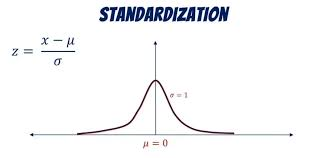


In [1]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
import numpy as np

# Load CSV (skip header), select numeric columns, drop ID column
raw = np.genfromtxt('Data_Africa.csv', delimiter=',', skip_header=1,
                     usecols=(1,4,5,6,7,8))  # Year, Population, GDP, Life_Exp, Urban%, Internet%

# Handle missing values: fill NaNs with column mean
col_means = np.nanmean(raw, axis=0)
inds = np.where(np.isnan(raw))
raw[inds] = np.take(col_means, inds[1])

data = raw

mean = np.mean(data, axis=0)
std = np.std(data, axis=0)

standardized_data = (data - mean) / std
standardized_data[:5]  # Display the first few rows of standardized data

array([[-1.6583124 ,  0.16158138, -0.39724597, -1.74018384, -1.48362266,
         0.15896051],
       [-1.50755672,  0.18718384, -0.40202249, -1.74018384,  0.91481401,
         1.73228413],
       [-1.35680105,  0.21418487, -0.40202249, -1.74018384,  0.48842527,
         0.50432423],
       [-1.20604538,  0.24251038, -0.39164488, -1.74018384, -0.25775503,
        -0.68526191],
       [-1.05528971,  0.27190513, -0.3736    , -1.72250926, -0.25775503,
         0.96480919]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [2]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(standardized_data, rowvar=False)
cov_matrix

array([[ 1.00075019,  0.10960715,  0.15684498,  0.01729854,  0.00512484,
        -0.01236866],
       [ 0.10960715,  1.00075019,  0.7375174 ,  0.04135522, -0.00394206,
         0.04161806],
       [ 0.15684498,  0.7375174 ,  1.00075019,  0.04918038, -0.00207506,
         0.03115288],
       [ 0.01729854,  0.04135522,  0.04918038,  1.00075019,  0.01811726,
         0.02050012],
       [ 0.00512484, -0.00394206, -0.00207506,  0.01811726,  1.00075019,
         0.01834718],
       [-0.01236866,  0.04161806,  0.03115288,  0.02050012,  0.01834718,
         1.00075019]])

**Why compute a covariance matrix?**
1. It quantifies how each pair of features varies together, revealing redundancy and relationships (e.g., GDP and Internet_Users_Percent may move together) that PCA can exploit to compress information.
2. It is the matrix whose eigenvectors/eigenvalues define the directions (principal components) of maximum variance, which is the mathematical foundation PCA needs to find a new, smaller set of uncorrelated axes.

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [3]:
# Step 4: Perform Eigendecomposition
# np.linalg.eigh is preferred for symmetric matrices (covariance matrices are symmetric)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
eigenvalues, eigenvectors

(array([0.26157568, 0.94185004, 0.97940121, 0.99474752, 1.03470377,
        1.79222291]),
 array([[-4.63112537e-02, -8.24620444e-01, -5.92064937e-03,
         -4.92643878e-01, -1.46972591e-01, -2.31349096e-01],
        [-7.02117666e-01,  1.77997640e-01, -4.81025682e-02,
          9.67152810e-02, -2.87936431e-02, -6.80331424e-01],
        [ 7.10458526e-01,  1.29641338e-01, -4.01116835e-02,
          5.13059205e-02, -3.94247857e-02, -6.87492725e-01],
        [-7.11869996e-03,  1.10377562e-01,  7.89679414e-01,
         -3.06676779e-01,  5.12750161e-01, -8.49068135e-02],
        [-1.47901060e-03,  2.00140907e-01, -6.03498429e-01,
         -5.02540364e-01,  5.85819215e-01,  3.25827913e-04],
        [ 9.04821796e-03, -4.68264347e-01, -9.07645910e-02,
          6.31441527e-01,  6.08209495e-01, -6.14103265e-02]]))

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [4]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]  # Sort eigenvectors accordingly
sorted_eigenvectors

array([[-2.31349096e-01, -1.46972591e-01, -4.92643878e-01,
        -5.92064937e-03, -8.24620444e-01, -4.63112537e-02],
       [-6.80331424e-01, -2.87936431e-02,  9.67152810e-02,
        -4.81025682e-02,  1.77997640e-01, -7.02117666e-01],
       [-6.87492725e-01, -3.94247857e-02,  5.13059205e-02,
        -4.01116835e-02,  1.29641338e-01,  7.10458526e-01],
       [-8.49068135e-02,  5.12750161e-01, -3.06676779e-01,
         7.89679414e-01,  1.10377562e-01, -7.11869996e-03],
       [ 3.25827913e-04,  5.85819215e-01, -5.02540364e-01,
        -6.03498429e-01,  2.00140907e-01, -1.47901060e-03],
       [-6.14103265e-02,  6.08209495e-01,  6.31441527e-01,
        -9.07645910e-02, -4.68264347e-01,  9.04821796e-03]])

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [5]:
# Step 6: Project Data onto Principal Components

# Decide number of components using a 95% explained-variance threshold
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)
num_components = np.argmax(cumulative_variance >= 0.95) + 1  # Decide on the number of principal components to keep

principal_components = sorted_eigenvectors[:, :num_components]
reduced_data = np.dot(standardized_data, principal_components)  # Project data onto the principal components
reduced_data[:5]

array([[ 0.68433214, -1.40999762,  2.19183228, -0.47527139,  0.78129353],
       [ 0.53948377,  0.9292572 ,  1.90794514, -2.06745874,  0.4042092 ],
       [ 0.56150742, -0.0903208 ,  1.27518038, -1.70086992,  0.77437112],
       [ 0.57303472, -1.27434682,  0.82801508, -1.14525035,  1.06414173],
       [ 0.40292154, -0.28541002,  1.79401799, -1.28409147,  0.17667849]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [6]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
print(f'Number of Components Selected: {num_components}')
print(f'Cumulative Explained Variance: {cumulative_variance[num_components-1]:.4f}')
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (1334, 5)
Number of Components Selected: 5
Cumulative Explained Variance: 0.9564


array([[ 0.68433214, -1.40999762,  2.19183228, -0.47527139,  0.78129353],
       [ 0.53948377,  0.9292572 ,  1.90794514, -2.06745874,  0.4042092 ],
       [ 0.56150742, -0.0903208 ,  1.27518038, -1.70086992,  0.77437112],
       [ 0.57303472, -1.27434682,  0.82801508, -1.14525035,  1.06414173],
       [ 0.40292154, -0.28541002,  1.79401799, -1.28409147,  0.17667849]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

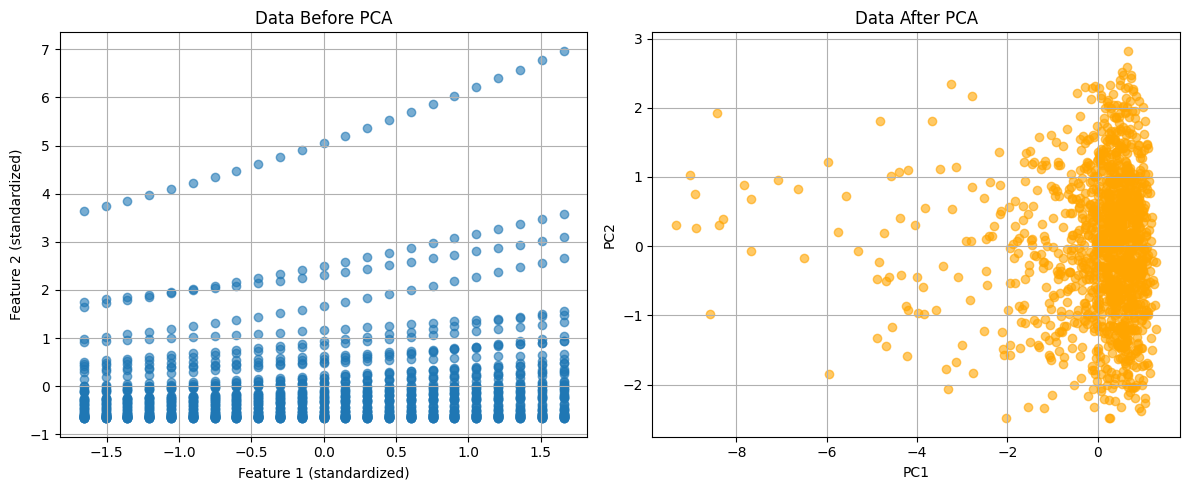

In [7]:
# Step 8: Visualize Before and After PCA
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot original data (first two features for simplicity)
axes[0].scatter(standardized_data[:, 0], standardized_data[:, 1], alpha=0.6)
axes[0].set_xlabel('Feature 1 (standardized)')
axes[0].set_ylabel('Feature 2 (standardized)')
axes[0].set_title('Data Before PCA')
axes[0].grid(True)

# Plot reduced data after PCA
axes[1].scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.6, color='orange')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Data After PCA')
axes[1].grid(True)

plt.tight_layout()
plt.show()

**1. Interpretation of before/after PCA:** The original scatter (Feature 1 vs Feature 2) shows a loose, somewhat correlated spread across two raw standardized indicators. After PCA, the points are re-projected onto PC1 and PC2, the directions of maximum variance, producing a tighter, more spread-out distribution along PC1 that captures most of the dataset's variation.

**2. Component selection & tradeoffs:** We selected the smallest number of components whose cumulative explained variance reaches 95%, balancing dimensionality reduction against information retention. Keeping more components preserves more variance/detail but reduces compression benefits, while fewer components simplify the data and speed up analysis at the cost of losing some nuance.

**3. Information lost:** Reducing dimensions discards the variance captured in the lower-ranked components, meaning subtle, country-specific differences in indicators like economic activity (GDP) versus population pressure (Population, Urban_Population_Percent) that don't align with the dominant variance directions become harder to distinguish in the reduced representation.